In [30]:

import os
import numpy as np
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import seaborn as sns

SEED = 46  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✅ Global seed set to {SEED}")


✅ Global seed set to 46


In [31]:

DATASET_PATH = r"C:\Users\pc\Downloads\weed_dataset\dataset"  

class_folders = sorted([f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))])
print(f"Found {len(class_folders)} classes: {class_folders}")

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_folders)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
print(f"Class mapping: {class_to_idx}")

Found 4 classes: ['broadleaf', 'grass', 'soil', 'soybean']
Class mapping: {'broadleaf': 0, 'grass': 1, 'soil': 2, 'soybean': 3}


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001
RANDOM_STATE = 101
TRAIN_COUNT = 7000
TEST_COUNT = 3000
TRAIN_TEST_SPLIT_RATIO = 0.8
NUM_EMBEDDINGS = 512
EMBEDDINGS_DIM = 64
BETA = 0.25
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
IN_CHANNELS = 3
EARLY_STOPPING_PATIENCE = 5

In [37]:

def split_dataset(dataset_path, class_folders, train_ratio=0.8, random_state=RANDOM_STATE):
    
    train_data = []
    val_data = []
    
    for class_name in class_folders:
        class_path = os.path.join(dataset_path, class_name)
        class_idx = class_to_idx[class_name]
        
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG', '*.tif']:
            image_files.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Class '{class_name}': {len(image_files)} images")
        
        train_files, val_files = train_test_split(
            image_files, 
            train_size=train_ratio, 
            random_state=random_state,
            shuffle=True
        )
        
        train_data.extend([(f, class_idx) for f in train_files])
        val_data.extend([(f, class_idx) for f in val_files])
    
    print(f"\nTrain set: {len(train_data)} images")
    print(f"Validation set: {len(val_data)} images")
    
    return train_data, val_data


train_data, val_data = split_dataset(DATASET_PATH, class_folders, train_ratio=0.8)

Class 'broadleaf': 1191 images
Class 'grass': 3520 images
Class 'soil': 3249 images
Class 'soybean': 7376 images

Train set: 12267 images
Validation set: 3069 images


In [38]:

class ImageDataset(Dataset):
    def __init__(self, data_list, img_size=IMG_SIZE, augment=False):
        
        self.data_list = data_list
        self.img_size = img_size
        self.augment = augment
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        if self.augment:
            if random.random() > 0.5:
                img = cv2.flip(img, 1)
            
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)
        
        img = img.astype(np.float32) / 255.0
        
        img = torch.from_numpy(img).permute(2, 0, 1)
        
        return img, label


train_dataset = ImageDataset(train_data, img_size=IMG_SIZE, augment=True)
val_dataset = ImageDataset(val_data, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 384
Validation batches: 96


# Testing VQ VAE Model

In [39]:
import torch
import unittest
from torchinfo import summary
import sys
import os

# For Jupyter notebook, get the current working directory
notebook_dir = os.getcwd()
sys.path.insert(0, notebook_dir)

# Direct import (not relative import for notebooks)
from vq_vae import VQVAE  # Remove the dot for notebook imports


class TestVQVAE(unittest.TestCase):

    def setUp(self) -> None:
        """Set up test fixtures before each test method."""
        self.img_size = IMG_SIZE
        self.in_channels = 3
        self.num_embeddings = 512
        self.embedding_dim = 64
        self.batch_size = 2
        
        self.model = VQVAE(
            in_channels=self.in_channels,
            num_embeddings=self.num_embeddings,
            embedding_dim=self.embedding_dim,
            img_size=self.img_size
        )
        self.model.eval()

    def test_model_instantiation(self):
        """Test if model can be instantiated."""
        self.assertIsNotNone(self.model)
        print("✅ Model instantiation successful")

    def test_model_summary(self):
        """Test model summary with torchinfo."""
        print("\n" + "="*50)
        print("MODEL SUMMARY")
        print("="*50)
        summary(
            self.model, 
            input_size=(self.batch_size, self.in_channels, self.img_size, self.img_size),
            device='cpu',
            col_names=["input_size", "output_size", "num_params", "trainable"]
        )
        print("✅ Model summary generated successfully")

    def test_forward_pass(self):
        """Test forward pass with random data."""
        x = torch.randn(self.batch_size, self.in_channels, self.img_size, self.img_size)
        
        with torch.no_grad():
            output = self.model(x)
        
        # Check if output is a tuple/list (common for VAE models)
        if isinstance(output, (tuple, list)):
            reconstructed = output[0]
            print(f"✅ Forward pass successful")
            print(f"   Input shape: {x.shape}")
            print(f"   Output shape: {reconstructed.shape}")
            
            # Check channels match
            self.assertEqual(reconstructed.shape[0], x.shape[0], 
                           "Batch size should match")
            self.assertEqual(reconstructed.shape[1], x.shape[1], 
                           "Number of channels should match")
            
            # Warn if spatial dimensions don't match
            if reconstructed.shape[2:] != x.shape[2:]:
                print(f"⚠️  Spatial dimensions differ: {reconstructed.shape[2:]} vs {x.shape[2:]}")
        else:
            print(f"✅ Forward pass successful - Output shape: {output.shape}")

    def test_different_batch_sizes(self):
        """Test model with different batch sizes."""
        batch_sizes = [1, 2, 4]
        
        for bs in batch_sizes:
            x = torch.randn(bs, self.in_channels, self.img_size, self.img_size)
            with torch.no_grad():
                output = self.model(x)
            
            if isinstance(output, (tuple, list)):
                output = output[0]
            
            self.assertEqual(output.shape[0], bs,
                           f"Batch size {bs} should be preserved")
        
        print(f"✅ Model handles different batch sizes: {batch_sizes}")

    def test_model_device_compatibility(self):
        """Test model can be moved to different devices."""
        # Test CPU
        self.model.to('cpu')
        x = torch.randn(1, self.in_channels, self.img_size, self.img_size)
        with torch.no_grad():
            _ = self.model(x)
        print("✅ Model works on CPU")
        
        # Test CUDA if available
        if torch.cuda.is_available():
            self.model.to('cuda')
            x = x.to('cuda')
            with torch.no_grad():
                _ = self.model(x)
            print("✅ Model works on CUDA")
            self.model.to('cpu')  # Move back to CPU

    def test_loss_function(self):
        """Test loss computation if model has loss_function method."""
        # Use image size compatible with the model output (224 instead of 227)
        x = torch.randn(self.batch_size, self.in_channels, 224, 224)
        
        result = self.model(x)
        
        if hasattr(self.model, 'loss_function'):
            try:
                if isinstance(result, (tuple, list)):
                    # The model returns (recons, input, vq_loss)
                    # Component 0: 224x224 reconstruction
                    # Component 1: Original input (should be 224x224 now)
                    # Component 2: VQ loss (scalar)
                    
                    recons = result[0]
                    print(f"ℹ️  Reconstruction shape: {recons.shape}")
                    print(f"ℹ️  Input shape in result: {result[1].shape if isinstance(result[1], torch.Tensor) else 'N/A'}")
                    
                    loss = self.model.loss_function(*result)
                else:
                    loss = self.model.loss_function(result, x)
                
                print(f"✅ Loss computation successful")
                
                # Handle different loss return types
                if isinstance(loss, dict):
                    print(f"   Loss breakdown:")
                    for k, v in loss.items():
                        if isinstance(v, torch.Tensor):
                            print(f"     {k}: {v.item():.6f}")
                        else:
                            print(f"     {k}: {v}")
                elif isinstance(loss, (tuple, list)):
                    total_loss = loss[0]
                    if isinstance(total_loss, torch.Tensor):
                        print(f"   Total loss: {total_loss.item():.6f}")
                    else:
                        print(f"   Total loss: {total_loss:.6f}")
                    
                    if len(loss) > 1 and isinstance(loss[1], dict):
                        print(f"   Loss components:")
                        for k, v in loss[1].items():
                            if isinstance(v, torch.Tensor):
                                print(f"     {k}: {v.item():.6f}")
                            else:
                                print(f"     {k}: {v}")
                else:
                    if isinstance(loss, torch.Tensor):
                        print(f"   Loss value: {loss.item():.6f}")
                    else:
                        print(f"   Loss value: {loss}")
                    
                self.assertIsNotNone(loss, "Loss should not be None")
                
            except Exception as e:
                print(f"❌ Loss computation failed: {str(e)}")
                print(f"   Model output components:")
                if isinstance(result, (tuple, list)):
                    for i, component in enumerate(result):
                        if isinstance(component, torch.Tensor):
                            print(f"     Component {i}: Tensor with shape {component.shape}")
                        else:
                            print(f"     Component {i}: {type(component)}")
                raise
        else:
            print("ℹ️  Model does not have loss_function method")

    def test_output_components(self):
        """Test what components the model returns."""
        x = torch.randn(self.batch_size, self.in_channels, self.img_size, self.img_size)
        
        with torch.no_grad():
            output = self.model(x)
        
        if isinstance(output, (tuple, list)):
            print(f"✅ Model returns {len(output)} components:")
            for i, component in enumerate(output):
                if isinstance(component, torch.Tensor):
                    print(f"   Component {i}: Tensor with shape {component.shape}")
                else:
                    print(f"   Component {i}: {type(component)}")
        else:
            print(f"✅ Model returns single output: {type(output)}")
    
    def test_loss_with_original_size(self):
        """Test if we need to resize inputs for loss computation with 227x227 images."""
        x_227 = torch.randn(self.batch_size, self.in_channels, 227, 227)
        
        with torch.no_grad():
            result = self.model(x_227)
        
        print(f"\n📊 Testing with 227x227 input:")
        print(f"   Input: {x_227.shape}")
        
        if isinstance(result, (tuple, list)):
            for i, component in enumerate(result):
                if isinstance(component, torch.Tensor):
                    print(f"   Output component {i}: {component.shape}")
        
        print(f"\n💡 Recommendation: Use 224x224 images for this model to avoid dimension mismatch")
        print(f"   Or modify the model architecture to preserve 227x227 dimensions")


# Run tests in notebook
if __name__ == '__main__':
    # Create test suite
    suite = unittest.TestLoader().loadTestsFromTestCase(TestVQVAE)
    runner = unittest.TextTestRunner(verbosity=2)
    runner.run(suite)

test_different_batch_sizes (__main__.TestVQVAE.test_different_batch_sizes)
Test model with different batch sizes. ... ok
test_forward_pass (__main__.TestVQVAE.test_forward_pass)
Test forward pass with random data. ... 

✅ Model handles different batch sizes: [1, 2, 4]


ok
test_loss_function (__main__.TestVQVAE.test_loss_function)
Test loss computation if model has loss_function method. ... 

✅ Forward pass successful
   Input shape: torch.Size([2, 3, 256, 256])
   Output shape: torch.Size([2, 3, 256, 256])


ok
test_loss_with_original_size (__main__.TestVQVAE.test_loss_with_original_size)
Test if we need to resize inputs for loss computation with 227x227 images. ... 

...

✅ Model instantiation successful

MODEL SUMMARY


ok
test_output_components (__main__.TestVQVAE.test_output_components)
Test what components the model returns. ... 

✅ Model summary generated successfully


ok

----------------------------------------------------------------------
Ran 8 tests in 2.754s

OK


✅ Model returns 3 components:
   Component 0: Tensor with shape torch.Size([2, 3, 256, 256])
   Component 1: Tensor with shape torch.Size([2, 3, 256, 256])
   Component 2: Tensor with shape torch.Size([])


# Model Instanstiation

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from datetime import datetime

# Initialize model
model = VQVAE(
    in_channels=IN_CHANNELS,
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=EMBEDDINGS_DIM,
    img_size=IMG_SIZE,
    beta=BETA
).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=LR_SCHEDULER_FACTOR, 
    patience=LR_SCHEDULER_PATIENCE, 
    verbose=True
)

# Create checkpoint directory
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Best model path
best_model_path = os.path.join(checkpoint_dir, f"best_vqvae_{IMG_SIZE}.pth")

print(f"Model initialized")
print(f"Device: {device}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Best model will be saved to: {best_model_path}")


Model initialized
Device: cuda
Learning Rate: 0.0001
Batch Size: 32
Epochs: 15
Image Size: 256x256
Best model will be saved to: checkpoints\best_vqvae_256.pth


d:\D-Documents\University\sem7_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [41]:

def train_epoch(model, train_loader, optimizer, device, epoch):
    model.train()
    
    total_loss = 0
    total_recons_loss = 0
    total_vq_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [Train]')
    
    for batch_idx, (images, _) in enumerate(progress_bar):
        images = images.to(device)
        
        # Forward pass
        recons, input_img, vq_loss = model(images)
        
        # Compute loss
        loss_dict = model.loss_function(recons, input_img, vq_loss)
        loss = loss_dict['loss']
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update metrics
        total_loss += loss.item()
        total_recons_loss += loss_dict['Reconstruction_Loss'].item()
        total_vq_loss += vq_loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'recons': f'{loss_dict["Reconstruction_Loss"].item():.4f}',
            'vq': f'{vq_loss.item():.4f}'
        })
    
    # Calculate average losses
    avg_loss = total_loss / len(train_loader)
    avg_recons_loss = total_recons_loss / len(train_loader)
    avg_vq_loss = total_vq_loss / len(train_loader)
    
    return {
        'loss': avg_loss,
        'recons_loss': avg_recons_loss,
        'vq_loss': avg_vq_loss
    }


def validate_epoch(model, val_loader, device, epoch):
    model.eval()
    
    total_loss = 0
    total_recons_loss = 0
    total_vq_loss = 0
    
    progress_bar = tqdm(val_loader, desc=f'Epoch {epoch}/{EPOCHS} [Val]')
    
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(progress_bar):
            images = images.to(device)
            
            # Forward pass
            recons, input_img, vq_loss = model(images)
            
            # Compute loss
            loss_dict = model.loss_function(recons, input_img, vq_loss)
            loss = loss_dict['loss']
            
            # Update metrics
            total_loss += loss.item()
            total_recons_loss += loss_dict['Reconstruction_Loss'].item()
            total_vq_loss += vq_loss.item()
            
            # Update progress bar
            progress_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'recons': f'{loss_dict["Reconstruction_Loss"].item():.4f}',
                'vq': f'{vq_loss.item():.4f}'
            })
    
    # Calculate average losses
    avg_loss = total_loss / len(val_loader)
    avg_recons_loss = total_recons_loss / len(val_loader)
    avg_vq_loss = total_vq_loss / len(val_loader)
    
    return {
        'loss': avg_loss,
        'recons_loss': avg_recons_loss,
        'vq_loss': avg_vq_loss
    }


print("Training and validation functions defined")


Training and validation functions defined


In [42]:
# Training history
history = {
    'train_loss': [],
    'train_recons_loss': [],
    'train_vq_loss': [],
    'val_loss': [],
    'val_recons_loss': [],
    'val_vq_loss': [],
    'learning_rates': []
}

# Best validation loss
best_val_loss = float('inf')

print("="*70)
print("STARTING TRAINING")
print("="*70)

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*70}")

    early_stopping_counter = 0
    
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, device, epoch)
    
    # Validate
    val_metrics = validate_epoch(model, val_loader, device, epoch)
    
    # Update learning rate
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_metrics['loss'])
    history['train_recons_loss'].append(train_metrics['recons_loss'])
    history['train_vq_loss'].append(train_metrics['vq_loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_recons_loss'].append(val_metrics['recons_loss'])
    history['val_vq_loss'].append(val_metrics['vq_loss'])
    history['learning_rates'].append(current_lr)
    
    # Print epoch summary
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch} SUMMARY")
    print(f"{'='*70}")
    print(f"Train Loss:        {train_metrics['loss']:.6f}")
    print(f"Train Recons Loss: {train_metrics['recons_loss']:.6f}")
    print(f"Train VQ Loss:     {train_metrics['vq_loss']:.6f}")
    print(f"Val Loss:          {val_metrics['loss']:.6f}")
    print(f"Val Recons Loss:   {val_metrics['recons_loss']:.6f}")
    print(f"Val VQ Loss:       {val_metrics['vq_loss']:.6f}")
    print(f"Learning Rate:     {current_lr:.6f}")
    
    # Save best model
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'history': history,
            'config': {
                'img_size': IMG_SIZE,
                'batch_size': BATCH_SIZE,
                'learning_rate': LEARNING_RATE,
                'num_embeddings': 512,
                'embedding_dim': 64
            }
        }
        
        early_stopping_counter = 0

        torch.save(checkpoint, best_model_path)
        print(f"\nBest model saved! Val Loss: {best_val_loss:.6f}")
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {EARLY_STOPPING_PATIENCE} epochs without improvement.")
            break
    
    print(f"{'='*70}\n")

print("\n" + "="*70)
print("TRAINING COMPLETED!")
print("="*70)
print(f"Best Validation Loss: {best_val_loss:.6f}")
print(f"Best model saved at: {best_model_path}")
print("="*70)


STARTING TRAINING

EPOCH 1/15


Epoch 1/15 [Val]: 100%|██████████| 96/96 [00:19<00:00,  4.95it/s, loss=226.5838, recons=0.0272, vq=226.5566]



EPOCH 1 SUMMARY
Train Loss:        28.466767
Train Recons Loss: 0.027606
Train VQ Loss:     28.439161
Val Loss:          210.175697
Val Recons Loss:   0.029415
Val VQ Loss:       210.146282
Learning Rate:     0.000100

✅ Best model saved! Val Loss: 210.175697


EPOCH 2/15


Epoch 2/15 [Val]: 100%|██████████| 96/96 [00:15<00:00,  6.11it/s, loss=0.4563, recons=0.0097, vq=0.4466]



EPOCH 2 SUMMARY
Train Loss:        462.553832
Train Recons Loss: 0.041691
Train VQ Loss:     462.512149
Val Loss:          0.313312
Val Recons Loss:   0.011218
Val VQ Loss:       0.302095
Learning Rate:     0.000100

✅ Best model saved! Val Loss: 0.313312


EPOCH 3/15


...


EPOCH 13 SUMMARY
Train Loss:        0.003878
Train Recons Loss: 0.001457
Train VQ Loss:     0.002421
Val Loss:          0.003034
Val Recons Loss:   0.001379
Val VQ Loss:       0.001655
Learning Rate:     0.000100

✅ Best model saved! Val Loss: 0.003034


EPOCH 14/15


Epoch 14/15 [Val]: 100%|██████████| 96/96 [00:15<00:00,  6.26it/s, loss=0.0018, recons=0.0010, vq=0.0008]



EPOCH 14 SUMMARY
Train Loss:        0.003371
Train Recons Loss: 0.001401
Train VQ Loss:     0.001971
Val Loss:          0.002895
Val Recons Loss:   0.001381
Val VQ Loss:       0.001514
Learning Rate:     0.000100

✅ Best model saved! Val Loss: 0.002895


EPOCH 15/15


Epoch 15/15 [Val]: 100%|██████████| 96/96 [00:15<00:00,  6.12it/s, loss=0.0014, recons=0.0008, vq=0.0006]



EPOCH 15 SUMMARY
Train Loss:        0.003541
Train Recons Loss: 0.001491
Train VQ Loss:     0.002050
Val Loss:          0.002453
Val Recons Loss:   0.001221
Val VQ Loss:       0.001231
Learning Rate:     0.000100

✅ Best model saved! Val Loss: 0.002453


TRAINING COMPLETED!
Best Validation Loss: 0.002453
Best model saved at: checkpoints\best_vqvae_256.pth


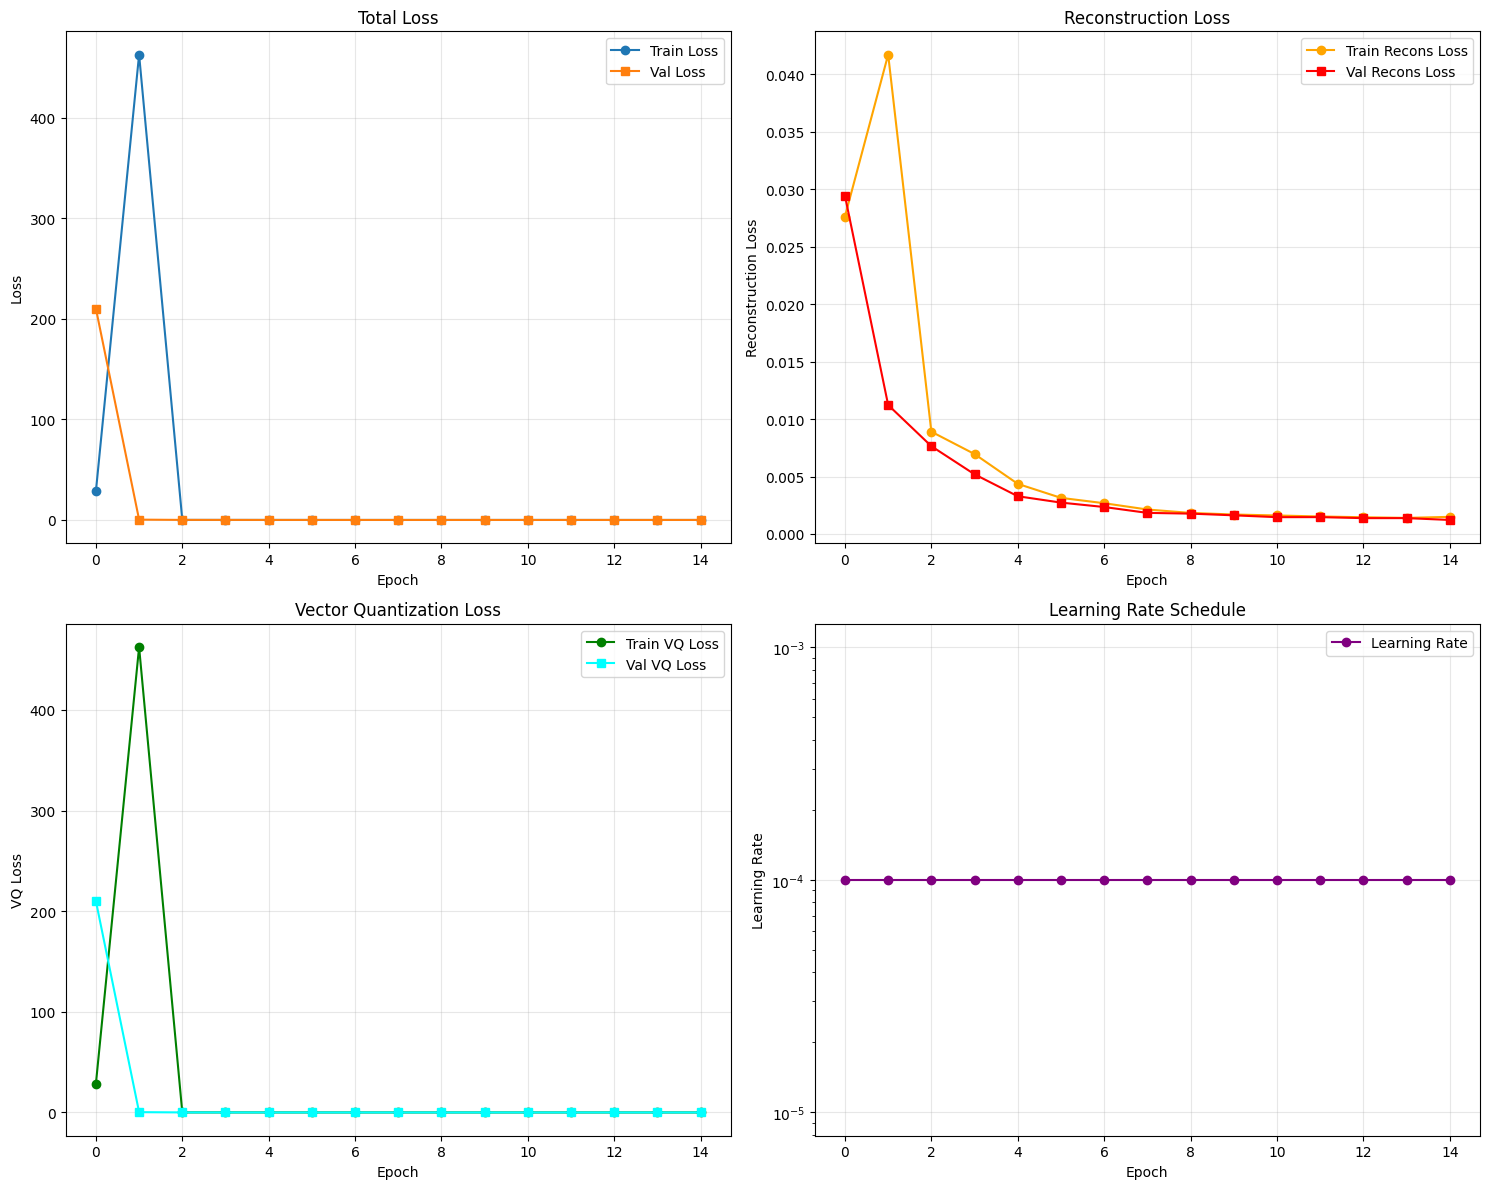

Training history plots saved


In [43]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Total Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Reconstruction Loss
axes[0, 1].plot(history['train_recons_loss'], label='Train Recons Loss', marker='o', color='orange')
axes[0, 1].plot(history['val_recons_loss'], label='Val Recons Loss', marker='s', color='red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: VQ Loss
axes[1, 0].plot(history['train_vq_loss'], label='Train VQ Loss', marker='o', color='green')
axes[1, 0].plot(history['val_vq_loss'], label='Val VQ Loss', marker='s', color='cyan')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('VQ Loss')
axes[1, 0].set_title('Vector Quantization Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Learning Rate
axes[1, 1].plot(history['learning_rates'], label='Learning Rate', marker='o', color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, f'training_history_{IMG_SIZE}.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Training history plots saved")


Loaded best model from epoch 15

Generating reconstruction visualizations...


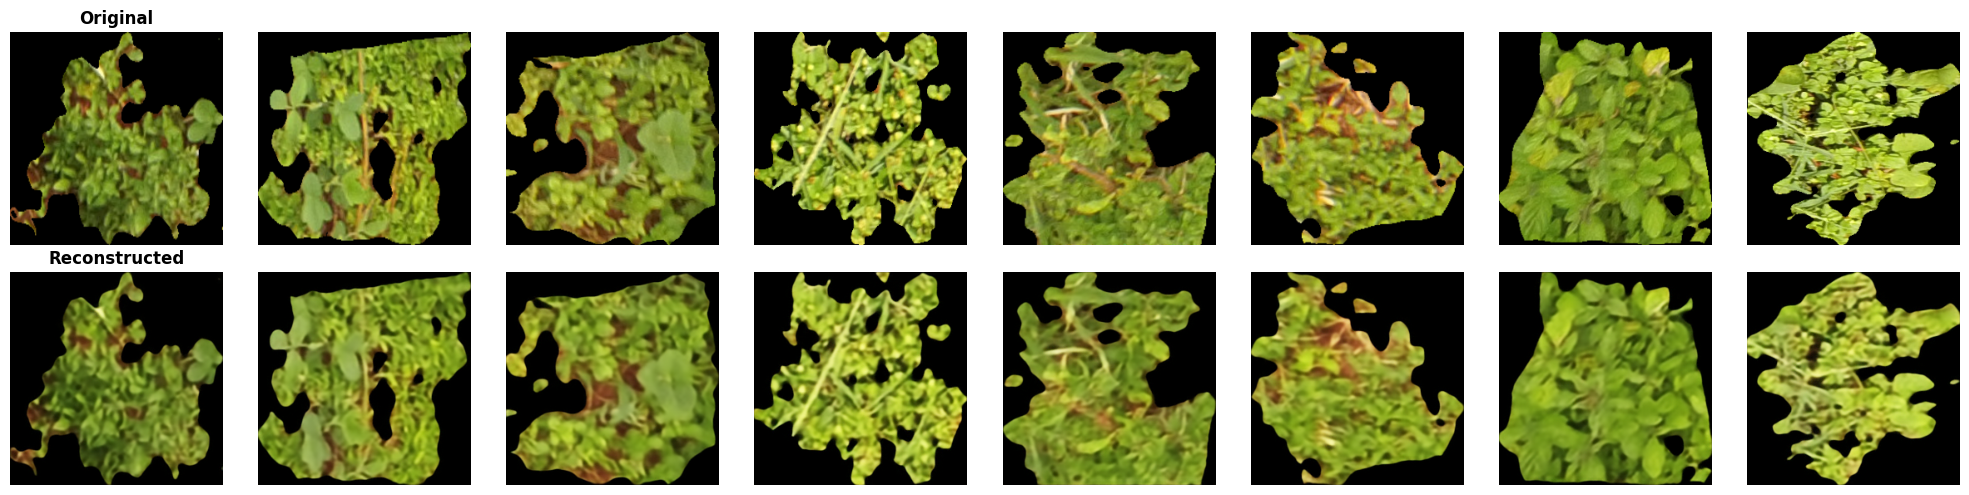

Reconstruction visualizations saved


In [44]:
# Visualize reconstructions
def visualize_reconstructions(model, data_loader, device, num_samples=8):
    """Visualize original images and their reconstructions"""
    model.eval()
    
    # Get a batch of images
    images, _ = next(iter(data_loader))
    images = images[:num_samples].to(device)
    
    with torch.no_grad():
        recons, _, _ = model(images)
    
    # Move to CPU and denormalize
    images = images.cpu()
    recons = recons.cpu()
    
    # Create figure
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 5))
    
    for i in range(num_samples):
        # Original image
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=12, fontweight='bold')
        
        # Reconstructed image
        rec = recons[i].permute(1, 2, 0).numpy()
        rec = np.clip(rec, 0, 1)
        axes[1, i].imshow(rec)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(checkpoint_dir, f'reconstructions_{IMG_SIZE}.png'), dpi=300, bbox_inches='tight')
    plt.show()


# Load best model for visualization
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")

# Visualize on validation set
print("\nGenerating reconstruction visualizations...")
visualize_reconstructions(model, val_loader, device, num_samples=8)
print("Reconstruction visualizations saved")


In [45]:
# Print final statistics
print("\n" + "="*70)
print("FINAL TRAINING STATISTICS")
print("="*70)

print("\nBest Epoch:", checkpoint['epoch'])
print(f"Best Validation Loss: {checkpoint['best_val_loss']:.6f}")

print("\nFinal Epoch Metrics:")
print(f"  Train Loss:        {history['train_loss'][-1]:.6f}")
print(f"  Train Recons Loss: {history['train_recons_loss'][-1]:.6f}")
print(f"  Train VQ Loss:     {history['train_vq_loss'][-1]:.6f}")
print(f"  Val Loss:          {history['val_loss'][-1]:.6f}")
print(f"  Val Recons Loss:   {history['val_recons_loss'][-1]:.6f}")
print(f"  Val VQ Loss:       {history['val_vq_loss'][-1]:.6f}")

print("\nImprovement from First Epoch:")
print(f"  Train Loss:        {history['train_loss'][0]:.6f} → {history['train_loss'][-1]:.6f} ({((history['train_loss'][-1] - history['train_loss'][0]) / history['train_loss'][0] * 100):.2f}%)")
print(f"  Val Loss:          {history['val_loss'][0]:.6f} → {history['val_loss'][-1]:.6f} ({((history['val_loss'][-1] - history['val_loss'][0]) / history['val_loss'][0] * 100):.2f}%)")

print("\nSaved Files:")
print(f"  Best Model: {best_model_path}")
print(f"  Training History Plot: {os.path.join(checkpoint_dir, f'training_history_{IMG_SIZE}.png')}")
print(f"  Reconstructions: {os.path.join(checkpoint_dir, f'reconstructions_{IMG_SIZE}.png')}")

print("="*70)



FINAL TRAINING STATISTICS

Best Epoch: 15
Best Validation Loss: 0.002453

Final Epoch Metrics:
  Train Loss:        0.003541
  Train Recons Loss: 0.001491
  Train VQ Loss:     0.002050
  Val Loss:          0.002453
  Val Recons Loss:   0.001221
  Val VQ Loss:       0.001231

Improvement from First Epoch:
  Train Loss:        28.466767 → 0.003541 (-99.99%)
  Val Loss:          210.175697 → 0.002453 (-100.00%)

Saved Files:
  Best Model: checkpoints\best_vqvae_256.pth
  Training History Plot: checkpoints\training_history_256.png
  Reconstructions: checkpoints\reconstructions_256.png
